### Using FinBERT to classify 3M+ Tweets sentiment

We first load, examine and clean our data Tweet data. We merge ```Tweet.csv``` with ```Company_Tweet.csv``` in order to obtain ticker data per tweet, without duplicata. We optimize this process using vectorization.

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=SyntaxWarning)

df_tweets = pd.read_csv("data/Tweet/Tweet.csv")
df_ticker = pd.read_csv("data/Tweet/Company_Tweet.csv")

df_ticker['ticker_symbol'] = df_ticker['ticker_symbol'].astype(str) + ', '
df_ticker_agg = df_ticker.groupby('tweet_id', as_index=False).sum()
df_ticker_agg['ticker_symbol'] = df_ticker_agg['ticker_symbol'].str.rstrip(', ')

df = pd.merge(df_tweets, df_ticker_agg, on='tweet_id', how='left')
dates = pd.to_datetime(df['post_date'], unit='s')

print(f"Total tweets: {len(df)}")

Total tweets: 3717964


Our dataset contains 3,717,964 tweets: it is necessary to clean this mass of data entries.

Many of these tweets are irrelevant to current financial market conditions and use the $Cashtags system solely for advertising purposing. Examples include: 
- Give your brain a workout with Squares – Challenging Puzzle Game http://dlvr.it/7zTvGm #AppAdvice $AAPL
- Swing Trading: Up To 8.91% Return In 14 Days http://ow.ly/GDkrZ #swingtrading #forecast #techstock $MWW $AAPL $TSLA
- S&P100 #Stocks Performance $HD $LOW $SBUX $TGT $DVN $IBM $AMZN $F $APA $GM $MS $HAL $DIS $MCD $BMY $XOM  more@ http://12Stocks.com/sp100
- $UNP $ORCL $QCOM $MSFT $AAPL Top scoring mega caps right now at the end of 2014 on http://GetAOM.com
- http://BiloSelhi.com subscribers alerted to 10-250% gain options. JOIN NOW $QQQ $AAPL 
- Free course - Capital usage with Options http://bit.ly/CapiEffi $GLD $SLV $TSLA
- Algo Trading: Up to 61.09% Return In 1 Year http://ow.ly/GVxVm #tech #stocks $AAPL $TSLA
- #toptickertweets $AAPL $SPDC $SPY $TSLA $CLDN $YELP $TWTR $FB $FXE $EWG #sentiquant 20150427 18:00:04:186
- THE BINARY OPTIONS COMPETITION WIN $100,000 http://rbn.cm/VbMIHH $LNKD $AAPL $GOOGL $GOOLD #bones #options #forex #forextrading #Bonus

We should remove these tweets from our dataset: they don't carry relevant information for markets and are purely noise.

Hence, we filter out: 
- Advertisements detected with suspicious keywords
- Tweets including over 3+ stock tickers: they seek visibility instead of providing relevant information reflecting market sentiment

To facilitate finBERT sentiment analysis and limit tweet length, we also delete from all URLs textual content (they can sometimes be lenghty and go over our token limit). After this, our heaviest tweet went from 809 to 202 tokens.

In [18]:
# Removing tweets with spam keywords
keywords = ["JOIN NOW", "subscriber", "#AppAdvice", "Free course",
            "Free courses", "Competition", "free trial", "sign up",
            "join our", "free trial", "sign up", "join our", "Sign up",
            "In 14 days", "Algo Trading", "Algorithmic Trading",
            "Premium Package", "Stock Picking by Algorithms", "Top 10 Stock Picks",
            "AI-Based Algorithms""#Stocks Trend", "#Stocks Performance", "12Stocks.com",
            "ow.ly", "SUBSCRIBE", "subscribers", "#howtotrade"]

spam_pattern = "|".join(keywords)
df_spam = df[~df['body'].str.contains(spam_pattern, case=True, na=False)]
print(f"{len(df)-len(df_spam)} tweets removed after spam-keywords cleaning")

# Remove tweets with more than 4 cashtags
cashtag_regex = r'\$[a-zA-Z]{2,4}(?=\s|,|$)'
ticker_count = df['body'].str.findall(cashtag_regex).str.len()
df_cashtag = df[ticker_count <= 4].copy()
print(f"{len(df)-len(df_cashtag)} tweets removed after cashtag filtering")

df = pd.merge(df_spam, df_cashtag, how='inner')
df = df.reset_index(drop=True)

# Removing lengthy links (http://, https://, www.) from the body of the tweets
df['body'] = df['body'].str.replace(r'https?://\S+|(?:\w+\.)+\w+/\S*', '', regex=True)

dates = pd.to_datetime(df['post_date'], unit='s')


0 tweets removed after spam-keywords cleaning
0 tweets removed after cashtag filtering


We then compute basic descriptive metrics of the global datasets, as well as metrics regarding individual stocks.

In [3]:
# Metrics
print(f"Total tweets: {len(df)}")
print(f"Earliest tweet: {dates.min()}")
print(f"Latest tweet: {dates.max()}")

companies = {"AAPL": "AAPL", "GOOGL": "GOOG", "AMZN": "AMZN", "TSLA": "TSLA", "MSFT": "MSFT"}
stats_d = []
stats_w = []

for name, ticker in companies.items():
    sub_df = df[df['ticker_symbol'].str.contains(ticker, na=False)]

    counts_daily = sub_df.groupby(dates.dt.date).size()
    counts_weekly = sub_df.groupby(dates.dt.to_period('W')).size()

    stats_d.append({"Company": name, "Mean": counts_daily.mean(), "Median": counts_daily.median(), "Std": counts_daily.std(), "Min": counts_daily.min(), "Max": counts_daily.max()})
    stats_w.append({"Company": name, "Mean": counts_weekly.mean(), "Median": counts_weekly.median(), "Std": counts_weekly.std(), "Min": counts_weekly.min(), "Max": counts_weekly.max()})

total_daily = df.groupby(dates.dt.date).size()
total_weekly = df.groupby(dates.dt.to_period('W')).size()

stats_d.append({"Company": "Total", "Mean": total_daily.mean(), "Median": total_daily.median(),"Std": total_daily.std(), "Min": total_daily.min(), "Max": total_daily.max()})
stats_w.append({"Company": "Total", "Mean": total_weekly.mean(), "Median": total_weekly.median(),"Std": total_weekly.std(), "Min": total_weekly.min(), "Max": total_weekly.max()})

print(f"\nDaily {pd.DataFrame(stats_d).set_index('Company').rename_axis(None).round(2)}")
print(f"\nWeekly {pd.DataFrame(stats_w).set_index('Company').rename_axis(None).round(2)}")

Total tweets: 3213156
Earliest tweet: 2015-01-01 00:01:36
Latest tweet: 2019-12-31 23:55:53

Daily           Mean  Median     Std  Min   Max
AAPL    637.22   492.0  549.75    5  4886
GOOGL   276.13   209.5  218.25   23  2120
AMZN    288.34   260.0  234.75    7  3926
TSLA    513.96   326.0  542.58   13  6217
MSFT    152.63   109.5  143.62    5  2761
Total  1759.67  1643.0  982.60  173  7350

Weekly            Mean   Median      Std   Min    Max
AAPL    4424.08   3814.0  2530.41  1042  16066
GOOGL   1924.47   1552.5  1078.84   250   6174
AMZN    2009.60   1877.5   801.46   325   6232
TSLA    3582.00   2235.5  2928.27   387  17666
MSFT    1063.75    786.5   674.43   197   6222
Total  12263.95  11890.5  3784.54  2551  24640


Our tweet datasets extends over 5 years (2015-2019), covering 3,052,232 tweets. There are 1545 tweets per day on average, ranging from 156 to 7274 per day. This minimum indicates no missing days in our dataset. On a weekly basis, there are on average 11356 tweets.

The dataset covers 5 companies: Apple ($AAPL), Google ($GOOG and $GOOGL), Amazon ($AMZN), Tesla Inc. ($TSLA) and Microsoft ($MSFT). Apple is by far the most mentioned company, altough, Tesla surpasses it in both daily and weekly maximum mentions. 

Plotting these tweets frequencies allow us to grasp the distribution of tweets over time, both on a company basis and global basis.

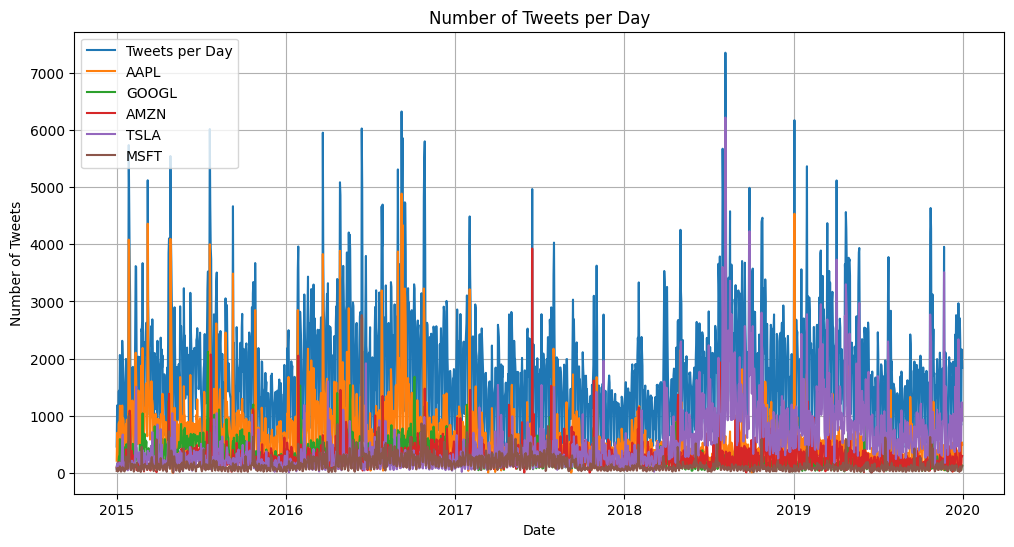

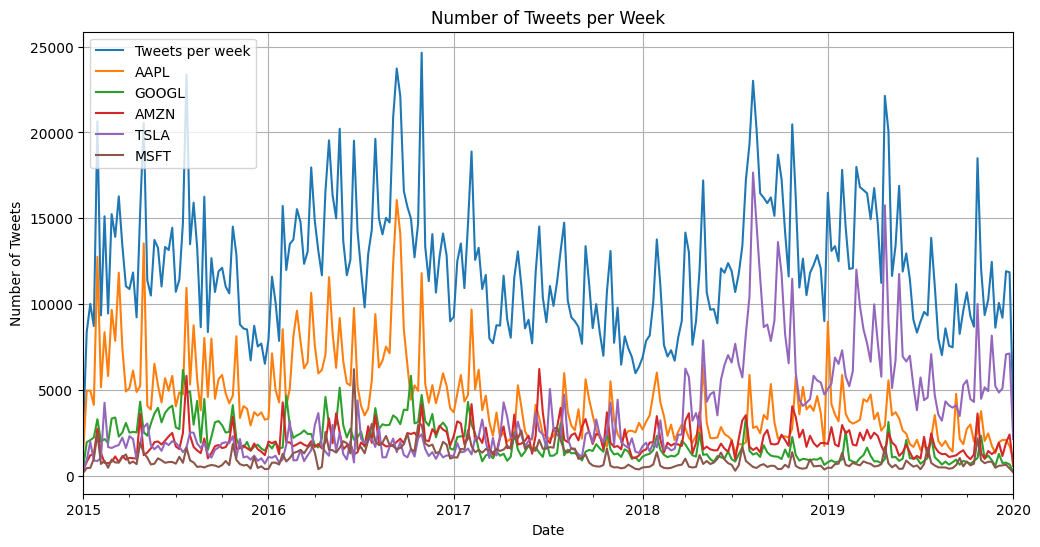

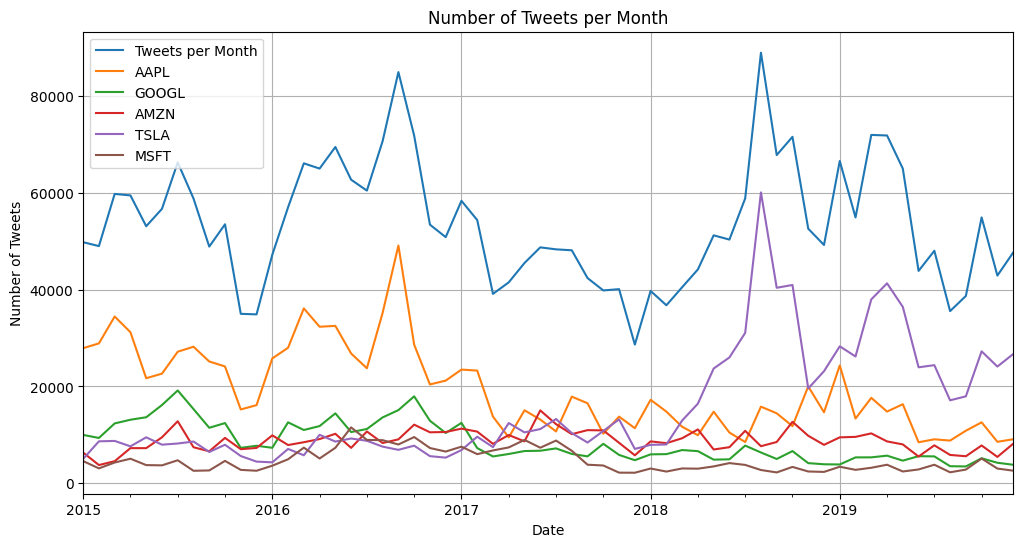

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

total_daily.plot(label="Tweets per Day")

for name, ticker in companies.items():
    sub_df = df[df['ticker_symbol'].str.contains(ticker, na=False)]
    counts_daily = sub_df.groupby(dates.dt.date).size()
    counts_daily.plot(label=name)

plt.title("Number of Tweets per Day")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid()
plt.legend(loc='upper left')
plt.show()


plt.figure(figsize=(12, 6))

total_weekly.plot(label="Tweets per week")

for name, ticker in companies.items():
    sub_df = df[df['ticker_symbol'].str.contains(ticker, na=False)]
    counts_weekly = sub_df.groupby(dates.dt.to_period('W')).size()
    counts_weekly.plot(label=name)

plt.title("Number of Tweets per Week")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid()
plt.legend(loc='upper left')
plt.show()


plt.figure(figsize=(12, 6))

total_monthly = df.groupby(dates.dt.to_period('M')).size()
total_monthly.plot(label="Tweets per Month")

for name, ticker in companies.items():
    sub_df = df[df['ticker_symbol'].str.contains(ticker, na=False)]
    counts_monthly = sub_df.groupby(dates.dt.to_period('M')).size()
    counts_monthly.plot(label=name)

plt.title("Number of Tweets per Month")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid()
plt.legend(loc='upper left')
plt.show()

We use FinBERT, a pre-trained NLP model, to analyse the sentiment of 3M tweets. FinBERT is built by further training on financial data of the BERT language model developed by Google. 


We load the model from ProsusAI/finbert on Hugging Face.

In [21]:
from transformers import pipeline
import torch

classifier = pipeline(
    "text-classification", 
    model="ProsusAI/finbert", 
    device=torch.device("mps"), # Apple Silicon M2 GPU
    dtype=torch.float16, 
    batch_size=512 # 16go RAM
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5878.55it/s]


In [22]:
from tqdm import tqdm

begin = 100000
to = 500000

df_slice = df.iloc[begin:to].copy()
tweets = df_slice['body'].fillna("").tolist()

results = []

for tweet in tqdm(tweets, desc="FinBERT"):
    out = classifier(tweet)[0]  
    results.append({
        'label': out['label'],
        'score': out['score']
    })

df_results = pd.DataFrame(results, index=df_slice.index)  
df_slice = pd.concat([df_slice, df_results], axis=1)

df_slice.to_csv(f"data/output/finBERT_{begin}_to_{to}.csv", index=True)

df.head(100)

FinBERT:   6%|▌         | 24290/400000 [08:27<2:10:52, 47.84it/s]


KeyboardInterrupt: 